## **About the Dataset(Metadata)**:
- Here Is the dataset overview:

| 🏷️ Column Name         | 📄 Description                               | 💡 Purpose / Role in Fraud Detection            |
| ----------------------- | -------------------------------------------- | ----------------------------------------------- |
| `trans_date_trans_time` | Date and time of the transaction             | Helps analyze time-based fraud patterns         |
| `cc_num`                | Credit card number (anonymized)              | Identifies unique cardholders                   |
| `merchant`              | Merchant or business name                    | Detects merchants linked to suspicious activity |
| `category`              | Type of transaction (e.g., shopping, travel) | Useful for behavioral segmentation              |
| `amt`                   | Transaction amount                           | High or unusual values may indicate fraud       |
| `first`                 | Cardholder’s first name                      | Identification (non-predictive)                 |
| `last`                  | Cardholder’s last name                       | Identification (non-predictive)                 |
| `gender`                | Gender of cardholder (0 = Female, 1 = Male)  | Behavioral analysis (optional feature)          |
| `street`                | Street address of the user                   | Helps detect geographical mismatches            |
| `city`                  | City of the user                             | Used for location-based fraud insights          |
| `state`                 | State of the user                            | Regional trend analysis                         |
| `zip`                   | ZIP or postal code                           | Region grouping for risk detection              |
| `lat`                   | Latitude of the transaction                  | Used to detect abnormal geo-locations           |
| `long`                  | Longitude of the transaction                 | Combined with latitude for fraud patterns       |
| `city_pop`              | Population of the user’s city                | Socioeconomic risk indicator                    |
| `job`                   | Occupation of the cardholder                 | Can reflect spending behavior and risk          |
| `dob`                   | Date of birth                                | Used to calculate age-related trends            |
| `trans_num`             | Unique transaction ID                        | Identifies each transaction record              |
| `unix_time`             | Transaction timestamp (in Unix format)       | Temporal analysis for fraud trends              |
| `merch_lat`             | Latitude of the merchant                     | Helps find distance-based frauds                |
| `merch_long`            | Longitude of the merchant                    | Cross-checks merchant and user location         |
| `is_fraud`              | 🚨 Target variable (1 = Fraud, 0 = Legit)    | The main column to predict                      |



## **Aims & Objectives**

### **Aim**

To build a powerful and efficient fraud detection system using Machine Learning algorithms, capable of accurately identifying fraudulent credit card transactions while minimizing false alarms.

---

### **Objectives**

1. **Data Understanding & Cleaning** – Explore and preprocess the dataset by handling missing values, encoding categorical columns, and scaling numerical features.
2. **Class Imbalance Handling** – Apply SMOTE to balance legitimate and fraudulent transactions for fair model training.
3. **Feature Analysis** – Investigate important patterns in transaction amount, location, and time to uncover fraud-related behaviors.
4. **Model Development** – Train and evaluate multiple ML models including Logistic Regression, Random Forest, Gradient Boosting, LightGBM, and XGBoost.
5. **Model Comparison** – Compare models using key metrics such as Accuracy, ROC-AUC, Precision, and Recall.
6. **Best Model Selection** – Select the most reliable model (XGBoost) achieving 99.9% ROC-AUC, ensuring strong fraud detection capability.
7. **Performance Validation** – Use Cross-Validation to confirm model consistency and prevent overfitting.
8. **Prediction & Insights** – Predict potential fraudulent transactions and interpret results to support secure financial operations.



## Step 1: Import libraries

- Let's import those libraries which are required for our analysis.

In [8]:
!pip install -U scikit-learn==1.5.2 imbalanced-learn==0.12.3 --quiet


In [9]:
!pip install xgboost --quiet

In [10]:
!pip install lightgbm --quiet

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from math import radians, sin, cos, sqrt, atan2
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load The Dataset.

In [12]:
df = pd.read_csv('fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Step 3: Understand our dataset.

In [13]:
df.shape

(1296675, 23)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [15]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01


In [17]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [18]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## Step 4: Data Preprocessing

- Let's Drop Unnecessary Columns.

In [19]:
df = df.drop(columns=['first', 'last', 'street', 'trans_num', 'cc_num']
)

In [20]:
df.head()

,Unnamed: 0,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


- Now we will convert `trans_date_trans_time` column into datetime format.

In [21]:

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])


df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)  # Saturday/Sunday = 1

# agar original column chahiye nahi to drop kar do
df.drop('trans_date_trans_time', axis=1, inplace=True)

df.head()


,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour,day_of_week,is_weekend
0,0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,1325376018,36.011293,-82.048315,0,2019,1,1,0,1,0
1,1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,1325376044,49.159047,-118.186462,0,2019,1,1,0,1,0
2,2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,1325376051,43.150704,-112.154481,0,2019,1,1,0,1,0
3,3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,1325376076,47.034331,-112.561071,0,2019,1,1,0,1,0
4,4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,1325376186,38.674999,-78.632459,0,2019,1,1,0,1,0


- Let's encode the Merchant Category column using Label Encoding.

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['merchant'] = le.fit_transform(df['merchant'])

In [23]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour,day_of_week,is_weekend
0,0,514,misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,1325376018,36.011293,-82.048315,0,2019,1,1,0,1,0
1,1,241,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,1325376044,49.159047,-118.186462,0,2019,1,1,0,1,0
2,2,390,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,1325376051,43.150704,-112.154481,0,2019,1,1,0,1,0
3,3,360,gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,1325376076,47.034331,-112.561071,0,2019,1,1,0,1,0
4,4,297,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,1325376186,38.674999,-78.632459,0,2019,1,1,0,1,0


In [24]:
df['merchant'].value_counts()

merchant
316    4403
105    3649
571    3634
349    3510
70     3493
       ... 
143     775
633     775
423     759
505     753
221     727
Name: count, Length: 693, dtype: int64

- Let's we make the the combo of the `merchent` and `category` column.

In [25]:
df['merchant_category_combo'] = df['merchant'].astype(str) + '_' + df['category'].astype(str)


- Now we calculates the distance (in kilometers) between the customer’s location and the merchant’s location using the **Haversine formula** and adds it as a new column called **`distance_km`** in the dataset.


In [26]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

df['distance_km'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)


In [27]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,merch_long,is_fraud,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km
0,0,514,misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,-82.048315,0,2019,1,1,0,1,0,514_misc_net,78.597568
1,1,241,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,-118.186462,0,2019,1,1,0,1,0,241_grocery_pos,30.212176
2,2,390,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,-112.154481,0,2019,1,1,0,1,0,390_entertainment,108.206083
3,3,360,gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,-112.561071,0,2019,1,1,0,1,0,360_gas_transport,95.673231
4,4,297,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,-78.632459,0,2019,1,1,0,1,0,297_misc_pos,77.556744


- Let's encode the `category` column using Label Encoding.

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category'] = le.fit_transform(df['category'])


In [29]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,merch_long,is_fraud,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km
0,0,514,8,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,-82.048315,0,2019,1,1,0,1,0,514_misc_net,78.597568
1,1,241,4,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,-118.186462,0,2019,1,1,0,1,0,241_grocery_pos,30.212176
2,2,390,0,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,-112.154481,0,2019,1,1,0,1,0,390_entertainment,108.206083
3,3,360,2,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,-112.561071,0,2019,1,1,0,1,0,360_gas_transport,95.673231
4,4,297,9,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,-78.632459,0,2019,1,1,0,1,0,297_misc_pos,77.556744


In [30]:
df.groupby('is_fraud')['amt'].value_counts()

is_fraud  amt    
0         1.14       542
          1.04       538
          1.25       535
          1.02       533
          1.01       523
                    ... 
1         1313.18      1
          1324.80      1
          1334.07      1
          1371.81      1
          1376.04      1
Name: count, Length: 55706, dtype: int64

In [31]:
df.columns

Index(['Unnamed: 0', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'year', 'month', 'day', 'hour',
       'day_of_week', 'is_weekend', 'merchant_category_combo', 'distance_km'],
      dtype='object')

In [32]:
df.zip.info

<bound method Series.info of 0          28654
1          99160
2          83252
3          59632
4          24433
           ...  
1296670    84735
1296671    21790
1296672    88325
1296673    57756
1296674    59871
Name: zip, Length: 1296675, dtype: int64>

In [33]:
zip_fraud_rate = df.groupby('zip')['is_fraud'].mean().reset_index()
zip_fraud_rate


,zip,is_fraud
0,1257,0.000000
1,1330,0.008729
2,1535,0.017476
3,1545,0.000000
4,1612,0.017341
...,...,...
965,99160,0.000000
966,99323,0.002722
967,99746,0.016667
968,99747,1.000000


In [34]:

zip_fraud_rate = df.groupby('zip')['is_fraud'].mean().reset_index()
zip_fraud_rate.columns = ['zip', 'zip_fraud_rate']

# ab isko main dataframe ke sath merge karo
df = df.merge(zip_fraud_rate, on='zip', how='left')

df.head()


,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,is_fraud,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km,zip_fraud_rate
0,0,514,8,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,0,2019,1,1,0,1,0,514_misc_net,78.597568,0.000000
1,1,241,4,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,0,2019,1,1,0,1,0,241_grocery_pos,30.212176,0.000000
2,2,390,0,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,0,2019,1,1,0,1,0,390_entertainment,108.206083,0.000000
3,3,360,2,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,0,2019,1,1,0,1,0,360_gas_transport,95.673231,0.030426
4,4,297,9,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,0,2019,1,1,0,1,0,297_misc_pos,77.556744,0.000000


In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['zip_encoded'] = le.fit_transform(df['zip'])


In [36]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,zip,lat,long,...,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km,zip_fraud_rate,zip_encoded
0,0,514,8,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,2019,1,1,0,1,0,514_misc_net,78.597568,0.000000,265
1,1,241,4,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,2019,1,1,0,1,0,241_grocery_pos,30.212176,0.000000,965
2,2,390,0,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,2019,1,1,0,1,0,390_entertainment,108.206083,0.000000,858
3,3,360,2,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,2019,1,1,0,1,0,360_gas_transport,95.673231,0.030426,614
4,4,297,9,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,2019,1,1,0,1,0,297_misc_pos,77.556744,0.000000,231


In [37]:
df.drop(columns=['zip'], inplace=True)

In [38]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,lat,long,city_pop,...,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km,zip_fraud_rate,zip_encoded
0,0,514,8,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,...,2019,1,1,0,1,0,514_misc_net,78.597568,0.000000,265
1,1,241,4,107.23,F,Orient,WA,48.8878,-118.2105,149,...,2019,1,1,0,1,0,241_grocery_pos,30.212176,0.000000,965
2,2,390,0,220.11,M,Malad City,ID,42.1808,-112.2620,4154,...,2019,1,1,0,1,0,390_entertainment,108.206083,0.000000,858
3,3,360,2,45.00,M,Boulder,MT,46.2306,-112.1138,1939,...,2019,1,1,0,1,0,360_gas_transport,95.673231,0.030426,614
4,4,297,9,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,...,2019,1,1,0,1,0,297_misc_pos,77.556744,0.000000,231


In [39]:
import numpy as np

df['amt'] = np.log1p(df['amt'])  # log1p = log(x+1)


<Axes: xlabel='amt', ylabel='Count'>

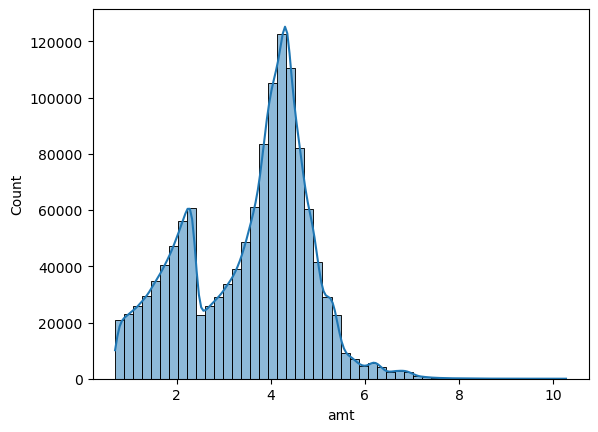

In [40]:
sns.histplot(df['amt'], kde=True, bins=50)

<Axes: xlabel='is_fraud', ylabel='count'>

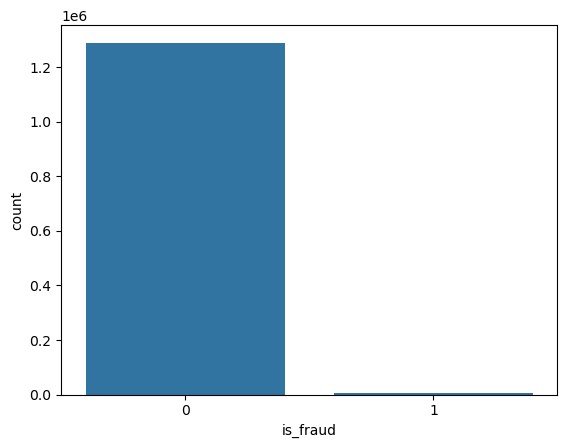

In [41]:
sns.countplot(x='is_fraud', data=df)

- Now we will encode all the categorical columns using Label Encoding.

In [42]:
df.select_dtypes(include=['object']).columns


Index(['gender', 'city', 'state', 'job', 'dob', 'merchant_category_combo'], dtype='object')

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


Now we splits the dataset into features (**X**) and target (**y**), then divides it into training and testing sets while keeping class balance using **stratify**.
After that, it applies **SMOTE** only on the training data to handle class imbalance by slightly increasing the number of fraud cases (making them about 10% of non-fraud cases).


In [44]:
# Step 1: Split X and y
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Step 2: Train-test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

# Step 3: Handle imbalance using SMOTE.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.1)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, y_train.value_counts().to_dict())
print("After SMOTE:", X_train_res.shape, y_train_res.value_counts().to_dict())


Before SMOTE: (1037340, 25) {0: 1031335, 1: 6005}
After SMOTE: (1134468, 25) {0: 1031335, 1: 103133}


In [45]:
import pandas as pd

df_resampled = pd.concat(
    [pd.DataFrame(X_train_res, columns=X.columns), 
     pd.Series(y_train_res, name='is_fraud')], 
    axis=1
)


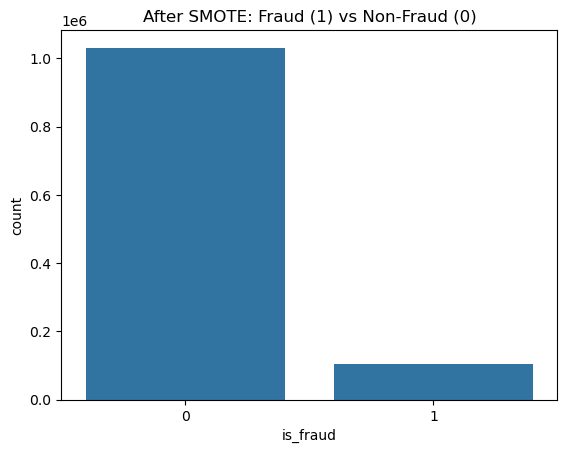

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud', data=df_resampled)
plt.title("After SMOTE: Fraud (1) vs Non-Fraud (0)")
plt.show()


In [47]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,lat,long,city_pop,...,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km,zip_fraud_rate,zip_encoded
0,0,514,8,1.786747,0,526,27,36.0788,-81.1781,3495,...,2019,1,1,0,1,0,465,78.597568,0.000000,265
1,1,241,4,4.684259,0,612,47,48.8878,-118.2105,149,...,2019,1,1,0,1,0,160,30.212176,0.000000,965
2,2,390,0,5.398660,1,468,13,42.1808,-112.2620,4154,...,2019,1,1,0,1,0,327,108.206083,0.000000,858
3,3,360,2,3.828641,1,84,26,46.2306,-112.1138,1939,...,2019,1,1,0,1,0,294,95.673231,0.030426,614
4,4,297,9,3.760269,1,216,45,38.4207,-79.4629,99,...,2019,1,1,0,1,0,221,77.556744,0.000000,231


In [48]:
df['gender'].value_counts()

gender
0    709863
1    586812
Name: count, dtype: int64

In [49]:
print(df['lat'].min(), df['lat'].max())
print(df['long'].min(), df['long'].max())


20.0271 66.6933
-165.6723 -67.9503


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['unix_time'] = scaler.fit_transform(df[['unix_time']])

<Axes: xlabel='unix_time', ylabel='Count'>

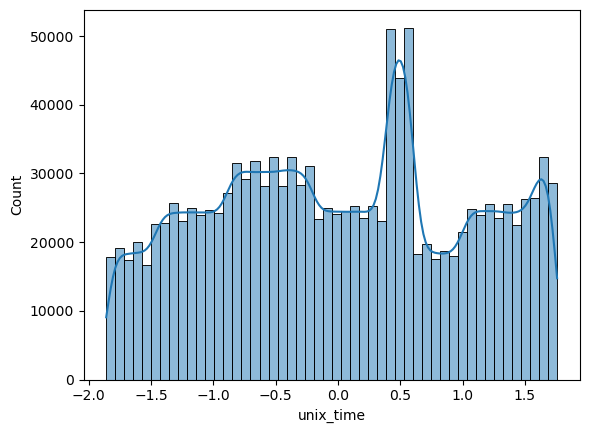

In [51]:
sns.histplot(df['unix_time'], bins=50, kde=True)

In [52]:
df.head()

,Unnamed: 0,merchant,category,amt,gender,city,state,lat,long,city_pop,...,year,month,day,hour,day_of_week,is_weekend,merchant_category_combo,distance_km,zip_fraud_rate,zip_encoded
0,0,514,8,1.786747,0,526,27,36.0788,-81.1781,3495,...,2019,1,1,0,1,0,465,78.597568,0.000000,265
1,1,241,4,4.684259,0,612,47,48.8878,-118.2105,149,...,2019,1,1,0,1,0,160,30.212176,0.000000,965
2,2,390,0,5.398660,1,468,13,42.1808,-112.2620,4154,...,2019,1,1,0,1,0,327,108.206083,0.000000,858
3,3,360,2,3.828641,1,84,26,46.2306,-112.1138,1939,...,2019,1,1,0,1,0,294,95.673231,0.030426,614
4,4,297,9,3.760269,1,216,45,38.4207,-79.4629,99,...,2019,1,1,0,1,0,221,77.556744,0.000000,231


<Axes: xlabel='gender', ylabel='count'>

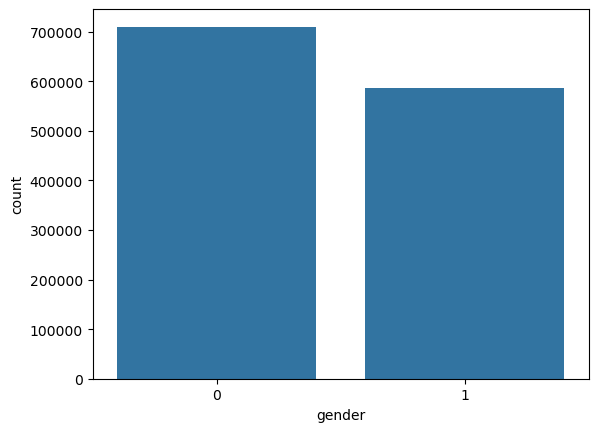

In [53]:
sns.countplot(x='gender', data=df)

## Step 5: Model Building and Evaluation

In [54]:

import pandas as pd
import numpy as np



X = df.drop(columns=['is_fraud'])
y = df['is_fraud']


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale Features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Fast & Powerful Models Only

models = {
    "Logistic Regression": LogisticRegression(max_iter=300, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.1, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1
    ),
}


# Train + Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc
    })

    print(f"\n================= {name} =================")
    print(f" Accuracy: {acc:.4f} |  ROC-AUC: {roc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    
# Compare Results
# 
results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
print("\n\n Model Comparison:")
print(results_df)

best_model = results_df.iloc[0]
print(f"\n Best Model: {best_model['Model']} | ROC-AUC: {best_model['ROC_AUC']:.4f}")



================= Logistic Regression =================
 Accuracy: 0.9947 |  ROC-AUC: 0.8677
Confusion Matrix:
 [[257755     79]
 [  1297    204]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.72      0.14      0.23      1501

    accuracy                           0.99    259335
   macro avg       0.86      0.57      0.61    259335
weighted avg       0.99      0.99      0.99    259335


================= Random Forest =================
 Accuracy: 0.9982 |  ROC-AUC: 0.9944
Confusion Matrix:
 [[257820     14]
 [   460   1041]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.99      0.69      0.81      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.85      0.91    259335
weighted avg       1.00      1.00      1.00    259335


=======

- Here we get very good ROC-AUC score of 99.9% using XGBoost model.

- Now we check the cross-validation score to ensure the model is not overfitting.

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

xgb = models['XGBoost']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())


Cross-validation ROC-AUC scores: [0.99873647 0.99845102 0.99888655 0.99887748 0.99904027]
Mean ROC-AUC: 0.9987983574654884


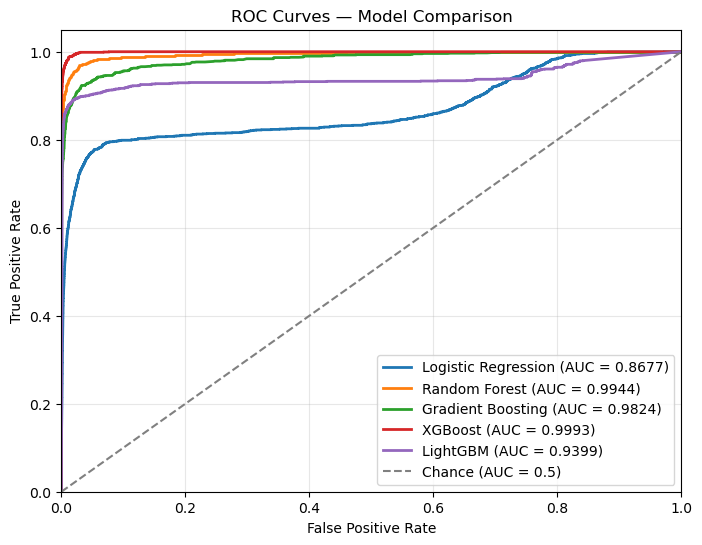

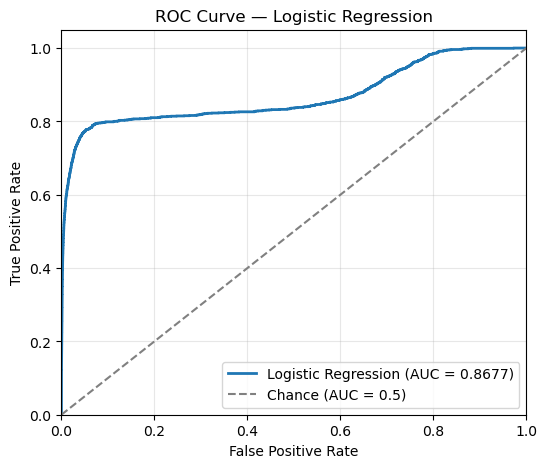

Saved: roc_plots/roc_logistic_regression.png


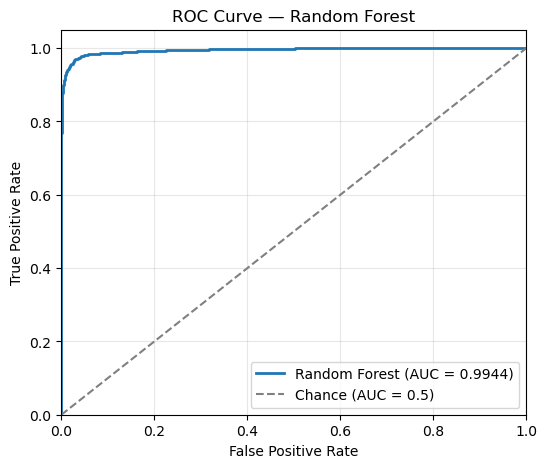

Saved: roc_plots/roc_random_forest.png


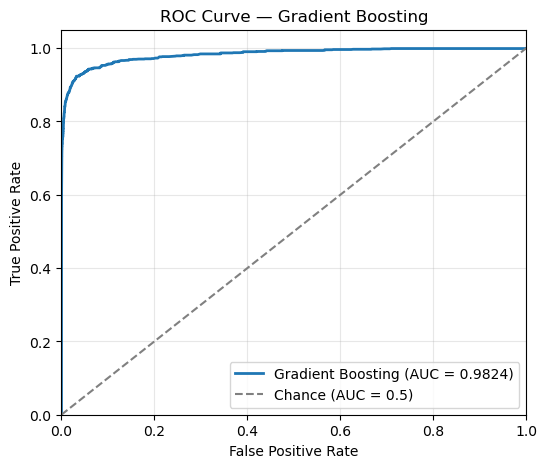

Saved: roc_plots/roc_gradient_boosting.png


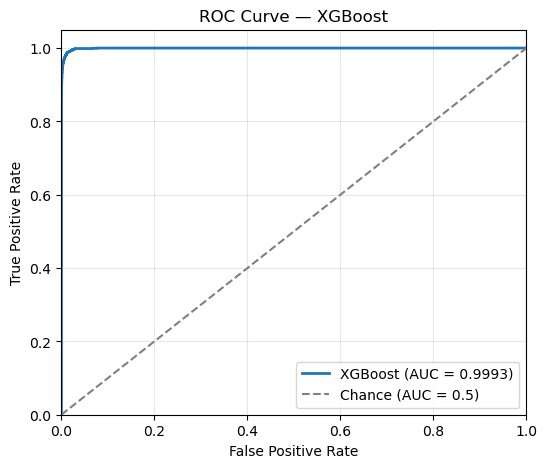

Saved: roc_plots/roc_xgboost.png


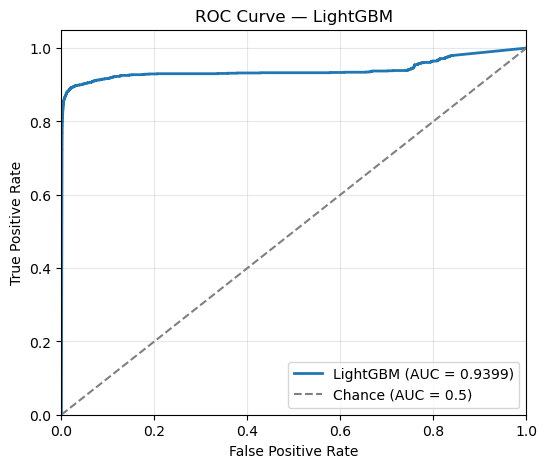

Saved: roc_plots/roc_lightgbm.png


In [66]:
# ...existing code...

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    # ensure model has predict_proba (if not, skip)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

# chance line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance (AUC = 0.5)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ...existing code...
# ...existing code...
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os
import numpy as np

os.makedirs("roc_plots", exist_ok=True)

for name, model in models.items():
    # obtain a score for ROC (probability or decision function)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        # normalize decision scores to [0,1] for plotting consistency
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)
    else:
        print(f"Skipping {name}: no predict_proba or decision_function")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
    plt.plot([0,1], [0,1], color="gray", linestyle="--", label="Chance (AUC = 0.5)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    # save plot with safe filename
    safe_name = "".join(c if c.isalnum() else "_" for c in name.lower())
    out_path = f"roc_plots/roc_{safe_name}.png"
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {out_path}")
# ...existing code...

## Step 6: Save the model

In [63]:
import joblib

# Save model
joblib.dump(models['XGBoost'], "best_xgboost_model.pkl")

# Load model when needed
model = joblib.load("best_xgboost_model.pkl")

# Predict new data
y_pred_new = model.predict(89)
print(y_pred_new)


[0]
